# Week-2 Assignment: End-to-End ML Pipeline on Tesla Dataset

**Name:** Rishu Singh  
**Program:** B.Tech CSE  
**University:** Maharishi Markandeshwar University, Mullana  

## Objective
This notebook demonstrates an end-to-end ML workflow using Tesla dataset and Week-2 concepts.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Dataset

In [2]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## EDA

In [3]:
print(df.shape)
print(df.columns)
df.info()
df.describe()

(2640, 12)
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-nul

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [4]:
print(df.isnull().sum())
print(df.duplicated().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
0


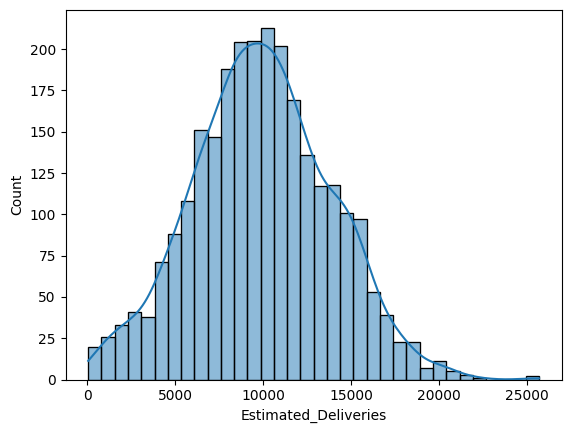

In [5]:
sns.histplot(df['Estimated_Deliveries'], kde=True)
plt.show()

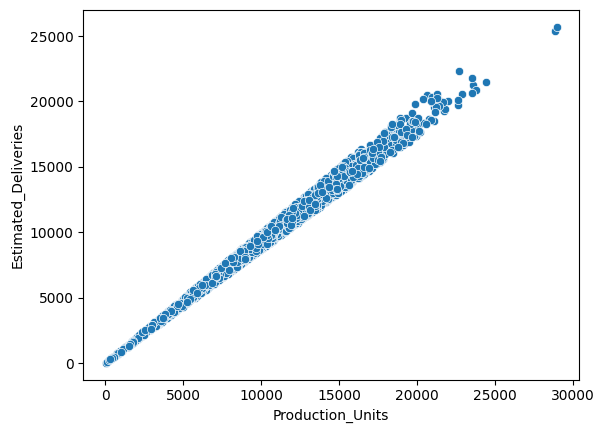

In [6]:
sns.scatterplot(x='Production_Units', y='Estimated_Deliveries', data=df)
plt.show()

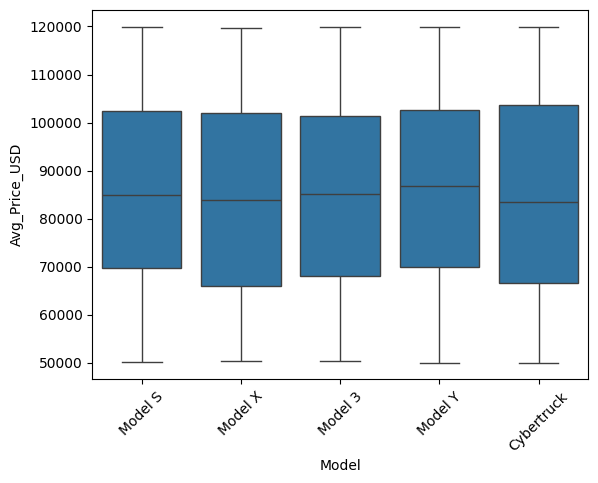

In [7]:
sns.boxplot(x='Model', y='Avg_Price_USD', data=df)
plt.xticks(rotation=45)
plt.show()

## Feature and Target

In [8]:
X = df.drop('Avg_Price_USD', axis=1)
y = df['Avg_Price_USD']

In [9]:
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

## Pipeline

In [10]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

## Linear Regression

In [12]:
linear_model = Pipeline(steps=[
('preprocessor', preprocessor),
('regressor', LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, linear_pred))
print("MSE:", mean_squared_error(y_test, linear_pred))
print("R2:", r2_score(y_test, linear_pred))

MAE: 16822.648507442376
MSE: 380741239.9980116
R2: -0.009621802206166485


## Ridge Regression

In [13]:
ridge_model = Pipeline(steps=[
('preprocessor', preprocessor),
('regressor', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

print("Ridge R2:", r2_score(y_test, ridge_pred))

Ridge R2: -0.009140923305599902


## Lasso Regression

In [14]:
lasso_model = Pipeline(steps=[
('preprocessor', preprocessor),
('regressor', Lasso(alpha=0.1))
])

lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

print("Lasso R2:", r2_score(y_test, lasso_pred))

Lasso R2: -0.009596546542880668


## Cross Validation

In [15]:
cv_scores = cross_val_score(linear_model, X, y, cv=5)
print(cv_scores)
print(cv_scores.mean())

[-0.01574286 -0.00387048 -0.00600153 -0.01576597  0.00200192]
-0.007875784730978119


## Hyperparameter Tuning

In [16]:
param_grid = {'regressor__alpha':[0.01,0.1,1,10]}

grid_model = Pipeline(steps=[
('preprocessor', preprocessor),
('regressor', Ridge())
])

grid = GridSearchCV(grid_model, param_grid, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'regressor__alpha': 10}
-0.006006046192272037


## Prediction Plot

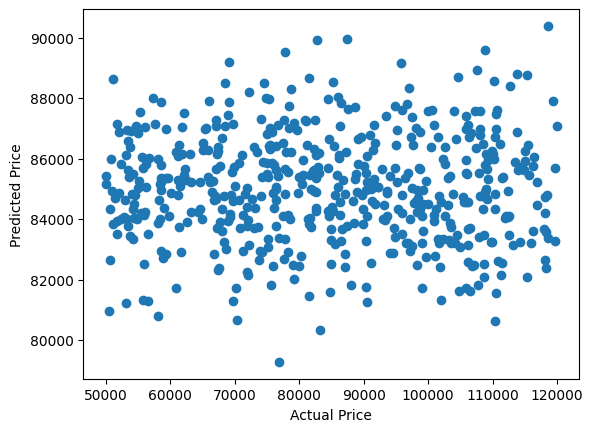

In [17]:
plt.scatter(y_test, linear_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

# Conclusion

This assignment applied Week-2 machine learning concepts on Tesla dataset.

### Observations
- Tesla models show price variation.
- Production and deliveries appear related.
- Ridge and Lasso support regularization.
- Pipeline improved workflow management.
